# Prompt - Task

Construye un modelo LSTM vanilla en TensorFlow/Keras para predecir el número de usuarios diarios de un sitio web, carga el dataset desde 'https://github.com/marsgr6/r-scripts/blob/master/data/viz_data/visitas_por_dia_web_cienciadedatos.csv' usando pandas con parse_dates en la columna 'date' y dayfirst=True, usa la columna 'users' como variable objetivo, realiza análisis exploratorio mostrando la serie de tiempo completa, crea secuencias temporales con lookback window de 30 días, divide los datos respetando el orden temporal (80% de las primeras observaciones para entrenamiento, 20% de las últimas observaciones para prueba), normaliza los datos con MinMaxScaler, construye una arquitectura LSTM con capas [LSTM(50 unidades, return_sequences=False), Dropout(0.2), Dense(1)], compila con optimizer Adam y loss MSE, entrena el modelo con early stopping y validation_split=0.1, realiza predicciones en el conjunto de prueba, desnormaliza las predicciones y valores reales, calcula métricas de evaluación (MSE, RMSE, MAE, MAPE), y genera tres gráficos: (1) serie de tiempo completa mostrando train/test split con línea vertical divisoria, (2) zoom del período de prueba con valores observados vs predichos incluyendo fechas en el eje x, y (3) curvas de pérdida durante el entrenamiento (training y validation loss).

- **Nota:** Es posible que tenga que insistir a Gemini en la ejecución de las taras. Dividir el prompt en diferentes elementos puede funcionar mejor.

## Cargar el dataset

### Subtask:
Cargar el dataset desde la URL proporcionada en GitHub usando pandas, asegurando el parseo correcto de la columna 'date'.


**Reasoning**:
Import pandas, define the URL, load the data using pd.read_csv with date parsing, and display the head of the dataframe to verify.



In [14]:
import pandas as pd

url = 'https://github.com/marsgr6/r-scripts/raw/master/data/viz_data/visitas_por_dia_web_cienciadedatos.csv'
df = pd.read_csv(url, parse_dates=['date'], dayfirst=True)
display(df.head())

/tmp/ipython-input-2322786964.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(url, parse_dates=['date'], dayfirst=True)


,date,users
0,2020-07-01,2324
1,2020-07-02,2201
2,2020-07-03,2146
3,2020-07-04,1666
4,2020-07-05,1433


## Eda

### Subtask:
Mostrar la serie de tiempo completa para visualizar los datos y entender su comportamiento.


**Reasoning**:
Plot the 'users' column against the 'date' column to visualize the time series data and its behavior.



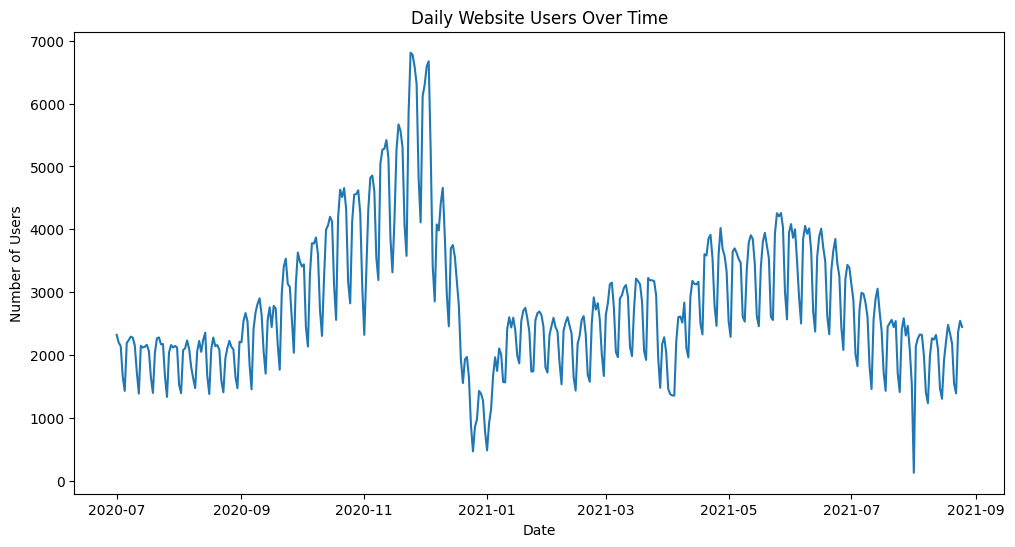

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['users'])
plt.xlabel('Date')
plt.ylabel('Number of Users')
plt.title('Daily Website Users Over Time')
plt.show()

## Preprocesamiento de datos

### Subtask:
Seleccionar la columna 'users' como variable objetivo, normalizar los datos utilizando `MinMaxScaler` y crear secuencias temporales con un `lookback window` de 30 días.


**Reasoning**:
Import MinMaxScaler, select the target variable, normalize it, and create sequences using a helper function.



In [16]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Select the 'users' column and reshape
target_data = df['users'].values.reshape(-1, 1)

# Initialize and fit the scaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(target_data)

# Define the sequence creation function
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback), 0])
        y.append(data[i + lookback, 0])
    return np.array(X), np.array(y)

# Create sequences with a lookback window of 30
lookback_window = 7
X, y = create_sequences(scaled_data, lookback_window)

print(f"Shape of input sequences (X): {X.shape}")
print(f"Shape of output values (y): {y.shape}")

Shape of input sequences (X): (414, 7)
Shape of output values (y): (414,)


## División de datos

### Subtask:
Dividir los datos en conjuntos de entrenamiento (80% inicial) y prueba (20% final), manteniendo el orden temporal.


**Reasoning**:
Determine the split index and divide the data into training and testing sets based on the 80/20 ratio while maintaining temporal order.



In [17]:
# Determine the split index (80% for training, 20% for testing)
split_index = int(len(X) * 0.8)

# Split the data into training and testing sets
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Print the shapes of the training and testing sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (331, 7)
Shape of y_train: (331,)
Shape of X_test: (83, 7)
Shape of y_test: (83,)


## Construir el modelo LSTM

### Subtask:
Definir la arquitectura del modelo LSTM en TensorFlow/Keras con capas [LSTM(50 unidades, return_sequences=False), Dropout(0.2), Dense(1)].

**Reasoning**:
Import necessary libraries from TensorFlow and Keras, define the sequential model, add the LSTM layer with 50 units and return_sequences=False, add a Dropout layer with a rate of 0.2, and finally add a Dense layer with 1 unit for the output.

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(Dense(units=1))

# Print the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

## Compilar el modelo

### Subtask:
Configurar el modelo con el optimizador Adam y la función de pérdida MSE.

**Reasoning**:
Compile the model using the Adam optimizer and Mean Squared Error (MSE) as the loss function.

In [19]:
# Compile the model
model.compile(optimizer='adam', loss='mse')

# Print a confirmation message
print("Model compiled successfully!")

Model compiled successfully!


## Entrenar el modelo

### Subtask:
Entrenar el modelo utilizando el conjunto de entrenamiento, implementando Early Stopping y `validation_split=0.1`.

**Reasoning**:
Import EarlyStopping, define the early stopping callback, and fit the model to the training data with the specified parameters.

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,  # You can increase the number of epochs, Early Stopping will stop training when necessary
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping]
)

print("Model training finished.")

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0850 - val_loss: 0.0234
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0158 - val_loss: 0.0138
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0160 - val_loss: 0.0094
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0140 - val_loss: 0.0126
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0124 - val_loss: 0.0084
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0129 - val_loss: 0.0087
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0099 - val_loss: 0.0094
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0105 - val_loss: 0.0087
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0117 - val_loss: 0.0085
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0102 - val_loss: 0.0085
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0098 - val_loss: 0.0089
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

**Reasoning**:
Plot the training and validation loss from the model's training history to visualize the learning process.

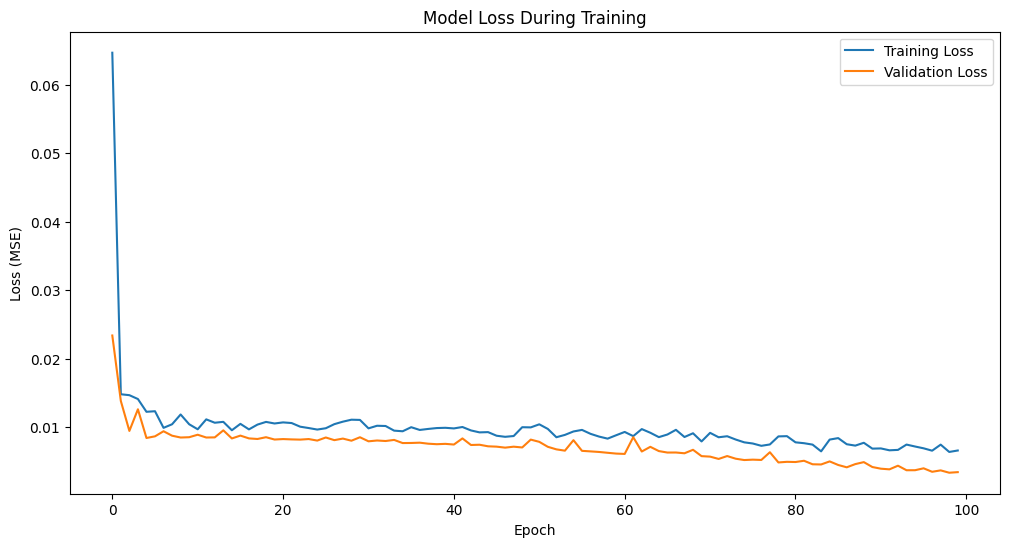

In [21]:
# Plot the training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

## Realizar predicciones

### Subtask:
Generar predicciones en el conjunto de prueba utilizando el modelo entrenado.

In [23]:
# Make predictions on the test set
predictions = model.predict(X_test)

print("Predictions on the test set have been generated.")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predictions on the test set have been generated.


## Post-procesamiento

### Subtask:
Desnormalizar las predicciones y los valores reales del conjunto de prueba a la escala original de los datos.

In [24]:
# Inverse transform the predictions and actual values
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print("Predictions and actual values have been denormalized.")

Predictions and actual values have been denormalized.


**Reasoning**:
Use the fitted scaler to inverse transform the scaled predictions and the actual y_test values to their original scale.

**Reasoning**:
Use the trained model to predict the 'users' values on the testing set (X_test).

## Evaluar el modelo

### Subtask:
Calcular métricas de evaluación (MSE, RMSE, MAE, MAPE) para evaluar el rendimiento del modelo.

**Reasoning**:
Import necessary metrics from sklearn.metrics and calculate Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and Mean Absolute Percentage Error (MAPE) using the denormalized actual values and predictions.

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate evaluation metrics
mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, predictions)
mape = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Squared Error (MSE): 150132.61
Root Mean Squared Error (RMSE): 387.47
Mean Absolute Error (MAE): 273.05
Mean Absolute Percentage Error (MAPE): 28.09%


## Visualizar resultados

### Subtask:
Generar los tres gráficos solicitados: (1) serie de tiempo completa mostrando train/test split con línea vertical divisoria, (2) zoom del período de prueba con valores observados vs predichos incluyendo fechas en el eje x, y (3) curvas de pérdida durante el entrenamiento (training y validation loss).

**Reasoning**:
Plot the full time series, highlighting the training and testing periods with different colors and adding a vertical line to indicate the split point.

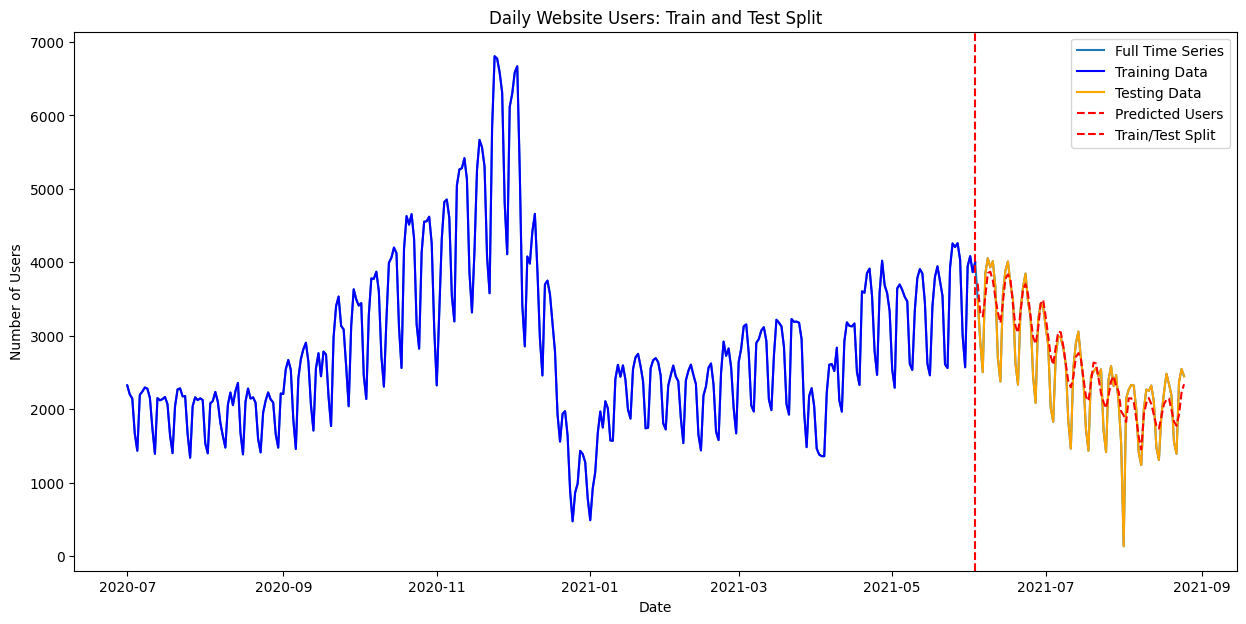

In [27]:
import matplotlib.pyplot as plt

# Get the dates for the test set
test_dates = df['date'][lookback_window + split_index:].reset_index(drop=True)

plt.figure(figsize=(15, 7))
plt.plot(df['date'], df['users'], label='Full Time Series')
plt.plot(df['date'][:lookback_window + split_index], df['users'][:lookback_window + split_index], label='Training Data', color='blue')
plt.plot(df['date'][lookback_window + split_index:], df['users'][lookback_window + split_index:], label='Testing Data', color='orange')
plt.plot(test_dates, predictions, label='Predicted Users', color='red', linestyle='--')

# Add a vertical line to show the split point
split_date = df['date'][lookback_window + split_index -1]
plt.axvline(split_date, color='red', linestyle='--', label='Train/Test Split')

plt.xlabel('Date')
plt.ylabel('Number of Users')
plt.title('Daily Website Users: Train and Test Split')
plt.legend()
plt.show()

**Reasoning**:
Plot the denormalized actual values against the denormalized predictions for the test set, using the test dates on the x-axis for better context.

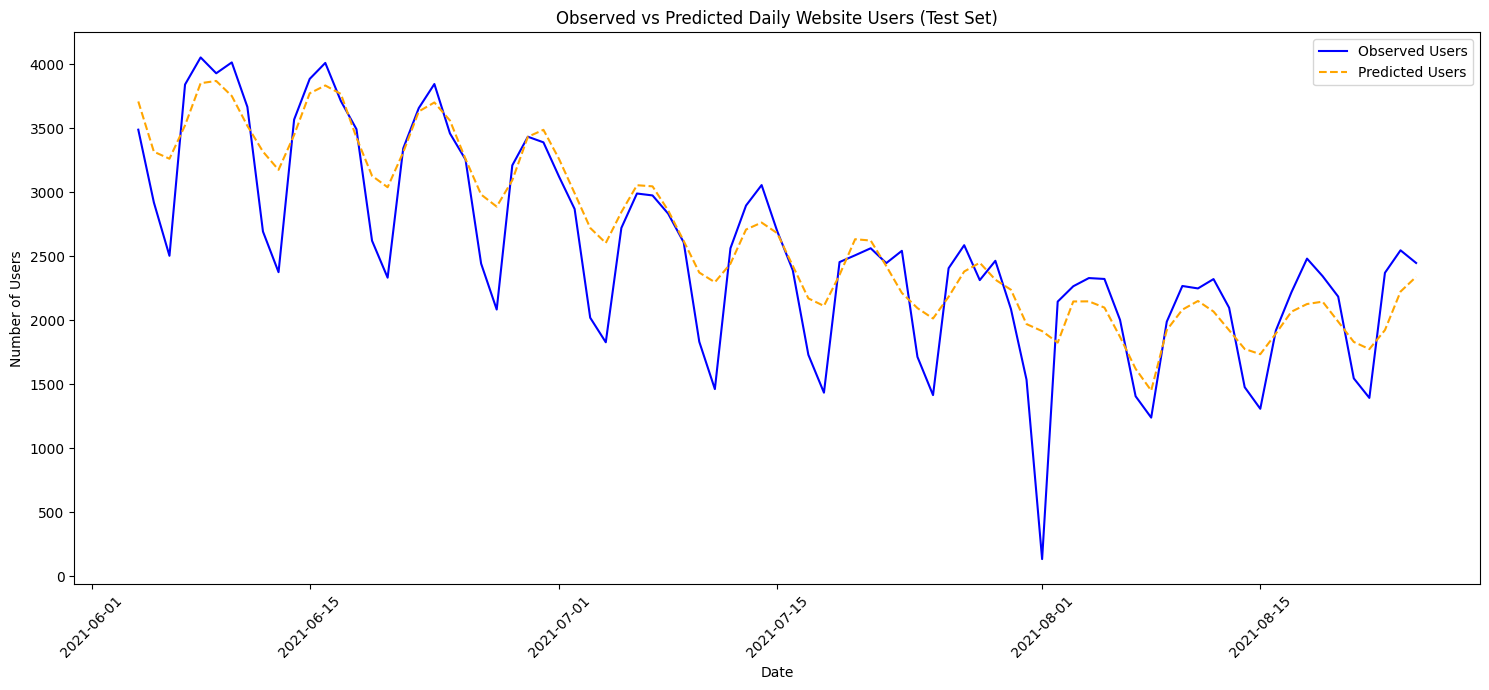

In [26]:
plt.figure(figsize=(15, 7))
plt.plot(test_dates, y_test_actual, label='Observed Users', color='blue')
plt.plot(test_dates, predictions, label='Predicted Users', color='orange', linestyle='--')

plt.xlabel('Date')
plt.ylabel('Number of Users')
plt.title('Observed vs Predicted Daily Website Users (Test Set)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()